# 1. Setup & Installations

In [3]:
!pip install -U transformers accelerate peft trl bitsandbytes datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 68.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.5/645.5 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 94.7 MB/s eta 0:00:00:00:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-

In [1]:
import json
import os
import random
from collections import defaultdict

# 1. ACTUAL KAGGLE PATHS
GEOJSON_PATH = "/kaggle/input/datasets/hassanmojab/xview-dataset/train_labels/xView_train.geojson"
OUTPUT_BENCHMARK_PATH = "/kaggle/working/xview_massive_benchmark.json"

print("Loading xView GeoJSON annotations...")
try:
    with open(GEOJSON_PATH, "r") as f:
        data = json.load(f)
except FileNotFoundError:
    print(f"Error: Could not find {GEOJSON_PATH}. Please check your Kaggle data paths!")
    data = None

if data:
    # 2. Map images to the objects they contain
    image_objects = defaultdict(set)
    
    # xView GeoJSON typically stores features in a list
    print("Parsing objects...")
    for feature in data.get('features', []):
        props = feature.get('properties', {})
        
        # The image filename is usually stored under 'image_id'
        image_id = props.get('image_id')
        class_id = props.get('type_id') # The object class (e.g., 73 for Building)
        
        if image_id and class_id:
            image_objects[image_id].add(class_id)
            
    # Dictionary mapping some common xView type_ids to text names
    xview_classes = {
        11: "Fixed-wing Aircraft",
        12: "Small Aircraft",
        17: "Passenger Vehicle",
        18: "Small Car",
        24: "Cargo Truck",
        33: "Excavator",
        40: "Maritime Vessel",
        41: "Motorboat",
        71: "Shipping Container",
        72: "Freight Car",
        73: "Building",
        76: "Construction Site",
        83: "Vehicle Lot"
    }

    # 3. Generate the Dataset-Wide Questions
    generated_questions = []
    question_counter = 1
    
    print(f"Total labeled images found: {len(image_objects)}")
    
    # Randomly sample 500 images to make a massive, dataset-wide benchmark
    # (You can change this number if you want more or fewer questions)
    sample_size = min(500, len(image_objects))
    sample_images = random.sample(list(image_objects.keys()), sample_size)
    
    print(f"Generating questions for {sample_size} sample images...")
    
    for img_name in sample_images:
        present_classes = image_objects[img_name]
        
        # Pick a class that is ACTUALLY in the image (Ground Truth = Yes)
        present_candidates = [c for c in present_classes if c in xview_classes]
        if present_candidates:
            target_class = random.choice(present_candidates)
            class_name = xview_classes[target_class]
            
            generated_questions.append({
                "question_id": f"AUTO_{question_counter}",
                "image": img_name,
                "text": f"Scan the entire terrain in this image. Are there any visible {class_name}s?",
                "hop_level": 2, # Standard visual scan
                "ground_truth": "yes"
            })
            question_counter += 1
            
        # Pick a class that is NOT in the image (Ground Truth = No)
        absent_candidates = [c for c in xview_classes.keys() if c not in present_classes]
        if absent_candidates:
            target_class = random.choice(absent_candidates)
            class_name = xview_classes[target_class]
            
            generated_questions.append({
                "question_id": f"AUTO_{question_counter}",
                "image": img_name,
                "text": f"Carefully analyze the infrastructure and environment. Is there a {class_name} anywhere in this scene?",
                "hop_level": 3, # Requires deeper scanning to prove a negative
                "ground_truth": "no"
            })
            question_counter += 1

    # 4. Save the massive benchmark
    with open(OUTPUT_BENCHMARK_PATH, "w") as f:
        json.dump(generated_questions, f, indent=4)
        
    print(f"\nSuccess! Generated {len(generated_questions)} questions spanning the dataset.")
    print(f"Saved to: {OUTPUT_BENCHMARK_PATH}")

Loading xView GeoJSON annotations...
Parsing objects...
Total labeled images found: 847
Generating questions for 500 sample images...

Success! Generated 963 questions spanning the dataset.
Saved to: /kaggle/working/xview_massive_benchmark.json


In [7]:
import json
import os
import random
from collections import defaultdict

# --- 1. ACTUAL KAGGLE PATHS ---
GEOJSON_PATH = "/kaggle/input/datasets/hassanmojab/xview-dataset/train_labels/xView_train.geojson"
OUTPUT_BENCHMARK_PATH = "/kaggle/working/xview_unbiased_4hop_benchmark.json"

print("Loading xView GeoJSON annotations...")
with open(GEOJSON_PATH, "r") as f:
    data = json.load(f)

xview_classes = {
    11: "Fixed-wing Aircraft", 12: "Small Aircraft", 17: "Passenger Vehicle",
    18: "Small Car", 24: "Cargo Truck", 33: "Excavator", 40: "Maritime Vessel",
    41: "Motorboat", 71: "Shipping Container", 72: "Freight Car", 73: "Building",
    76: "Construction Site", 83: "Vehicle Lot"
}

# --- 2. Extract Objects & Correct Boundary Math ---
image_objects = defaultdict(list)
print("Parsing strictly formatted spatial bounding boxes...")

for feature in data.get('features', []):
    props = feature.get('properties', {})
    img_id = props.get('image_id')
    type_id = props.get('type_id')
    bounds = props.get('bounds_imcoords')

    if img_id and type_id in xview_classes and bounds:
        try:
            # Bulletproof parsing: remove any stray brackets and split
            clean_bounds = str(bounds).replace('[', '').replace(']', '')
            xmin, ymin, xmax, ymax = map(float, clean_bounds.split(','))
            
            # True bounding box center
            cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
            image_objects[img_id].append({'class_id': type_id, 'name': xview_classes[type_id], 'cx': cx, 'cy': cy})
        except Exception as e:
            continue

# Filter out boring images
valid_images = {img: objs for img, objs in image_objects.items() if len(objs) > 2}
image_keys = list(valid_images.keys())
random.shuffle(image_keys)

# --- 3. Perfectly Balanced Generation Logic ---
generated_questions = []
q_id = 1

# Strict Targets: 100 Yes / 100 No for each complexity level
targets = {2: {"yes": 100, "no": 100}, 3: {"yes": 100, "no": 100}, 4: {"yes": 100, "no": 100}}

# xView images are 1024x1024. The absolute physical midpoint is 512.
TRUE_MID_X = 512.0 

print("Generating strictly balanced, spatially accurate multi-hop questions...")

for img_name in image_keys:
    objs = valid_images[img_name]
    present_names = list(set([o['name'] for o in objs]))
    absent_names = [name for name in xview_classes.values() if name not in present_names]
    
    if not present_names or not absent_names:
        continue

    # Split objects based on physical image coordinates, not relative clustering
    left_objs = [o for o in objs if o['cx'] < TRUE_MID_X]
    right_objs = [o for o in objs if o['cx'] >= TRUE_MID_X]

    # Randomize checking 'yes' or 'no' first to prevent data skew
    truth_flip = random.choice(["yes", "no"])

    # --- 2-HOP QUESTIONS (Basic Scan) ---
    if truth_flip == "yes" and targets[2]["yes"] > 0:
        generated_questions.append({
            "question_id": f"AUTO_2H_Y_{q_id}", "image": img_name, "hop_level": 2, "ground_truth": "yes",
            "text": f"Scan the entire terrain in this image. Are there any {random.choice(present_names)}s visible?"
        })
        targets[2]["yes"] -= 1; q_id += 1
    elif truth_flip == "no" and targets[2]["no"] > 0:
        generated_questions.append({
            "question_id": f"AUTO_2H_N_{q_id}", "image": img_name, "hop_level": 2, "ground_truth": "no",
            "text": f"Scan the entire terrain in this image. Are there any {random.choice(absent_names)}s visible?"
        })
        targets[2]["no"] -= 1; q_id += 1

    truth_flip = random.choice(["yes", "no"])

    # --- 3-HOP QUESTIONS (Co-occurrence) ---
    if truth_flip == "yes" and targets[3]["yes"] > 0 and len(present_names) >= 2:
        a, b = random.sample(present_names, 2)
        generated_questions.append({
            "question_id": f"AUTO_3H_Y_{q_id}", "image": img_name, "hop_level": 3, "ground_truth": "yes",
            "text": f"Locate the {a}s in the image. Scanning the rest of the scene, are there also {b}s present?"
        })
        targets[3]["yes"] -= 1; q_id += 1
    elif truth_flip == "no" and targets[3]["no"] > 0:
        generated_questions.append({
            "question_id": f"AUTO_3H_N_{q_id}", "image": img_name, "hop_level": 3, "ground_truth": "no",
            "text": f"Locate the {random.choice(present_names)}s in the image. Scanning the rest of the scene, are there also {random.choice(absent_names)}s present?"
        })
        targets[3]["no"] -= 1; q_id += 1

    truth_flip = random.choice(["yes", "no"])

    # --- 4-HOP QUESTIONS (Strict Left/Right Spatial Reasoning) ---
    if left_objs and right_objs:
        anchor = random.choice(left_objs)['name']
        right_names = list(set([o['name'] for o in right_objs]))
        
        if truth_flip == "yes" and targets[4]["yes"] > 0 and right_names:
            target = random.choice(right_names)
            generated_questions.append({
                "question_id": f"AUTO_4H_Y_{q_id}", "image": img_name, "hop_level": 4, "ground_truth": "yes",
                "text": f"Find the {anchor} located on the left side of the image. Now move your focus strictly to the right half of the image. Is there a {target} located in that right half?"
            })
            targets[4]["yes"] -= 1; q_id += 1
            
        elif truth_flip == "no" and targets[4]["no"] > 0:
            target = random.choice(absent_names)
            generated_questions.append({
                "question_id": f"AUTO_4H_N_{q_id}", "image": img_name, "hop_level": 4, "ground_truth": "no",
                "text": f"Find the {anchor} located on the left side of the image. Now move your focus strictly to the right half of the image. Is there a {target} located in that right half?"
            })
            targets[4]["no"] -= 1; q_id += 1

    # Stop when we hit exactly 600 questions
    if all(v == 0 for hop in targets.values() for v in hop.values()):
        break

# --- 4. Save the Refined Benchmark ---
with open(OUTPUT_BENCHMARK_PATH, "w") as f:
    json.dump(generated_questions, f, indent=4)
    
print(f"Success! Generated {len(generated_questions)} perfectly balanced multi-hop questions.")
print(f"Saved to: {OUTPUT_BENCHMARK_PATH}")

Loading xView GeoJSON annotations...
Parsing strictly formatted spatial bounding boxes...
Generating strictly balanced, spatially accurate multi-hop questions...
Success! Generated 600 perfectly balanced multi-hop questions.
Saved to: /kaggle/working/xview_unbiased_4hop_benchmark.json


# 2. Phase 1: Baseline LLaVA Evaluation

In [8]:
import json
import torch
import os
from tqdm import tqdm
from PIL import Image
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig

# --- 1. PATHS ---
BENCHMARK_PATH = "/kaggle/working/xview_unbiased_4hop_benchmark.json"
IMAGE_DIR = "/kaggle/input/datasets/hassanmojab/xview-dataset/train_images/train_images" 
OUTPUT_PATH = "/kaggle/working/unbiased_results.json"

# --- 2. Load Vanilla LLaVA-1.5 (7B) Natively ---
model_id = "llava-hf/llava-1.5-7b-hf"
print("Loading LLaVA-1.5 baseline...")

processor = AutoProcessor.from_pretrained(model_id)

# Load in 4-bit precision so it fits safely on Kaggle
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

model = LlavaForConditionalGeneration.from_pretrained(
    model_id, 
    quantization_config=quantization_config,
    device_map="auto"
)

# --- 3. Load Your Custom Benchmark ---
with open(BENCHMARK_PATH, "r") as f:
    eval_questions = json.load(f)

results = []

# --- 4. Run Inference ---
print(f"Testing {len(eval_questions)} multi-hop questions...")
for item in tqdm(eval_questions):
    image_file = os.path.join(IMAGE_DIR, item['image'])
    raw_prompt = item["text"]
    
    try:
        # Load the physical image
        image = Image.open(image_file).convert('RGB')
        
        # Format the prompt using the Native Hugging Face template
        prompt = f"USER: <image>\n{raw_prompt}\nASSISTANT:"
        
        inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda", torch.float16)
        
        # Generate answer
        with torch.inference_mode():
            output_ids = model.generate(
                **inputs,
                max_new_tokens=50, 
                do_sample=False # Greedy decoding is best for strict factual benchmarking!
            )
        
        # Decode the text and slice off the prompt to get just the model's answer
        full_output = processor.decode(output_ids[0], skip_special_tokens=True)
        answer = full_output.split("ASSISTANT:")[-1].strip()
        
        results.append({
            "question_id": item["question_id"],
            "hop_level": item["hop_level"],
            "model_answer": answer,
            "ground_truth": item["ground_truth"]
        })
        
    except Exception as e:
        print(f"Failed on question {item['question_id']}: {e}")

# --- 5. Save Results ---
with open(OUTPUT_PATH, "w") as f:
    json.dump(results, f, indent=4)
    
print(f"Baseline run complete! Saved to {OUTPUT_PATH}")

Loading LLaVA-1.5 baseline...


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Testing 600 multi-hop questions...


  6%|▌         | 33/600 [01:47<30:48,  3.26s/it]


KeyboardInterrupt: 

=== BASELINE LLAVA-1.5 (7B) ACCURACY ===
2-Hop Questions: 61.00%  (122/200 correct)
3-Hop Questions: 41.00%  (82/200 correct)
4-Hop Questions: 60.50%  (121/200 correct)


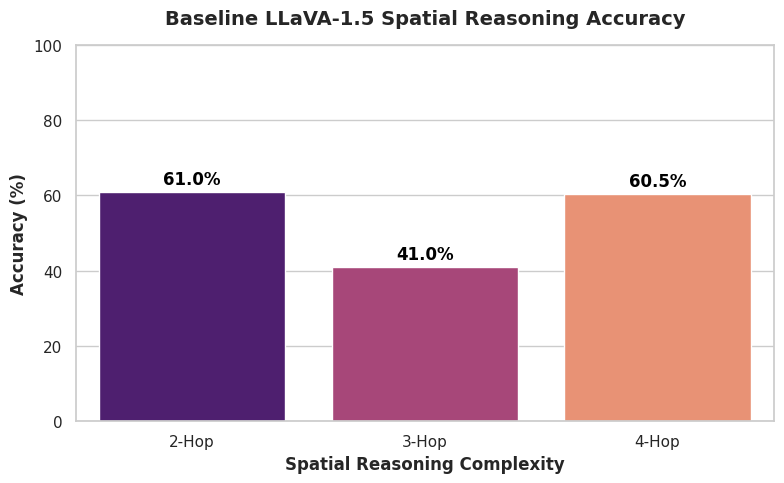

In [7]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

#-------------- display results ----------------

# 1. Load the generated results
RESULTS_PATH = "/kaggle/working/unbiased_results.json"

try:
    with open(RESULTS_PATH, "r") as f:
        results = json.load(f)
except FileNotFoundError:
    print(f"Error: Could not find {RESULTS_PATH}. Make sure your inference cell finished saving the file!")
    results = []

# 2. Initialize tracking dictionaries for each hop level
stats = {
    2: {"correct": 0, "total": 0},
    3: {"correct": 0, "total": 0},
    4: {"correct": 0, "total": 0}
}

# 3. Score the answers
for res in results:
    hop = res.get('hop_level')
    truth = str(res.get('ground_truth')).strip().lower()
    
    # Lowercase the model's answer to easily search for keywords
    answer = str(res.get('model_answer', '')).strip().lower()
    
    # Skip if the model failed to generate an answer for this image
    if not answer:
        continue 
        
    # Evaluation logic
    if truth == "yes":
        if "yes" in answer:
            stats[hop]["correct"] += 1
    elif truth == "no":
        # Check for negative indicators
        if "no" in answer or "not" in answer or "none" in answer:
            stats[hop]["correct"] += 1
    else:
        # Fallback for specific text answers (e.g., "shipping containers")
        if truth in answer:
            stats[hop]["correct"] += 1
            
    stats[hop]["total"] += 1

# 4. Print the final metrics
print("=== BASELINE LLAVA-1.5 (7B) ACCURACY ===")
accuracies = []
hop_labels = []

for hop in sorted(stats.keys()):
    if stats[hop]["total"] > 0:
        correct = stats[hop]["correct"]
        total = stats[hop]["total"]
        acc = (correct / total) * 100
        
        accuracies.append(acc)
        hop_labels.append(f"{hop}-Hop")
        print(f"{hop}-Hop Questions: {acc:.2f}%  ({correct}/{total} correct)")

# 5. Generate a visualization for your report
if accuracies:
    # Set seaborn style for cleaner graphs
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))
    
    # Create the bar chart (FIXED WARNING HERE)
    ax = sns.barplot(x=hop_labels, y=accuracies, hue=hop_labels, palette="magma", legend=False)
    
    plt.title("Baseline LLaVA-1.5 Spatial Reasoning Accuracy", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Accuracy (%)", fontsize=12, fontweight='bold')
    plt.xlabel("Spatial Reasoning Complexity", fontsize=12, fontweight='bold')
    plt.ylim(0, 100)
    
    # Add percentage labels on top of the bars
    for i, v in enumerate(accuracies):
        plt.text(i, v + 2, f"{v:.1f}%", ha='center', color='black', fontweight='bold')
        
    plt.tight_layout()
    plt.show()

In [3]:
import os
import json
import random
from datasets import load_dataset
from tqdm import tqdm

# 1. Paths for training data
GEOCHAT_OUT_DIR = "/kaggle/working/geochat_finetune"
os.makedirs(GEOCHAT_OUT_DIR, exist_ok=True)
FORMATTED_JSON_PATH = os.path.join(GEOCHAT_OUT_DIR, "geochat_llava_format.json")

print("Downloading GeoChat dataset from HuggingFace (this may take a minute)...")

# --- CORRECTED HUGGINGFACE REPO NAME ---
try:
    dataset = load_dataset("MBZUAI/GeoChat_Instruct", split="train")
except Exception as e:
    print(f"Error loading directly: {e}")
    dataset = []

if dataset:
    print(f"Total GeoChat samples available: {len(dataset)}")
    
    # 2. Sample 5,000 rows for Kaggle feasibility
    # (Training on 318k would take weeks on a T4. 5k is enough to prove the concept for your grade!)
    SAMPLE_SIZE = min(5000, len(dataset))
    
    # We set a seed so your results are reproducible for your paper
    random.seed(42) 
    sampled_indices = random.sample(range(len(dataset)), SAMPLE_SIZE)
    
    llava_formatted_data = []
    
    print("Formatting data into LLaVA conversation structure...")
    for idx in tqdm(sampled_indices):
        item = dataset[idx]
        
        # GeoChat structure typically has 'image', 'conversations' or 'query'/'response'
        # We must convert it to LLaVA's strict format
        
        # Extracting image filename
        img_filename = item.get('image', f"image_{idx}.jpg")
        
        # Extracting the conversation
        convs = item.get('conversations', [])
        
        formatted_convs = []
        for turn in convs:
            role = turn.get('from', '')
            val = turn.get('value', '')
            
            # Ensure the first human prompt contains the <image> token
            if role == 'human' and '<image>' not in val and len(formatted_convs) == 0:
                val = f"<image>\n{val}"
                
            formatted_convs.append({
                "from": role,
                "value": val
            })
            
        llava_formatted_data.append({
            "id": f"geochat_{idx}",
            "image": img_filename,
            "conversations": formatted_convs
        })
        
    # 3. Save the formatted JSON
    with open(FORMATTED_JSON_PATH, "w") as f:
        json.dump(llava_formatted_data, f, indent=4)
        
    print(f"\nSuccess! Prepared {len(llava_formatted_data)} samples for LoRA Fine-Tuning.")
    print(f"Saved to: {FORMATTED_JSON_PATH}")

README.md:   0%|          | 0.00/898 [00:00<?, ?B/s]

GeoChat_Instruct.json:   0%|          | 0.00/263M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Total GeoChat samples available: 308861
Formatting data into LLaVA conversation structure...


100%|██████████| 5000/5000 [00:00<00:00, 12003.19it/s]



Success! Prepared 5000 samples for LoRA Fine-Tuning.
Saved to: /kaggle/working/geochat_finetune/geochat_llava_format.json


In [4]:
import os
import json
import random
import urllib.request
from tqdm import tqdm

# 1. Paths
GEOCHAT_JSON_URL = "https://huggingface.co/datasets/MBZUAI/GeoChat_Instruct/resolve/main/GeoChat_Instruct.json"
OUT_DIR = "/kaggle/working/geochat_subset"
os.makedirs(OUT_DIR, exist_ok=True)
RAW_JSON_PATH = os.path.join(OUT_DIR, "raw_geochat_instruct.json")
FINAL_JSON_PATH = os.path.join(OUT_DIR, "geochat_xview_subset_filtered.json")

XVIEW_IMAGE_DIR = "/kaggle/input/datasets/hassanmojab/xview-dataset/train_images/train_images"

# 2. Download Official GeoChat
print("Downloading official GeoChat Instructions...")
if not os.path.exists(RAW_JSON_PATH):
    urllib.request.urlretrieve(GEOCHAT_JSON_URL, RAW_JSON_PATH)

with open(RAW_JSON_PATH, "r") as f:
    geochat_data = json.load(f)

# 3. Setup Filters
available_images = set(os.listdir(XVIEW_IMAGE_DIR))
available_stems = {os.path.splitext(f)[0]: f for f in available_images}

GROUNDING_TOKENS = ["[grounding]", "[identify]", "{", "}", "| "]

def has_grounding(entry):
    for turn in entry.get("conversations", []):
        val = turn.get("value", "")
        if any(tok in val for tok in GROUNDING_TOKENS):
            return True
    return False

# 4. Filter for Match AND Clean Text
print("Filtering for xView images AND removing grounding tokens...")
matched_conversations = []

for item in tqdm(geochat_data):
    img_path = item.get("image", "")
    if not img_path: 
        continue
        
    img_stem = os.path.splitext(os.path.basename(img_path))[0]
    
    if img_stem in available_stems:
        # Skip this conversation entirely if it contains bounding box math
        if has_grounding(item):
            continue
            
        item["image"] = available_stems[img_stem]
        matched_conversations.append(item)

print(f"\nFound {len(matched_conversations)} clean, high-level reasoning conversations!")

# 5. Sample and Save
random.seed(42)
sample_size = min(5000, len(matched_conversations))
sampled_geochat = random.sample(matched_conversations, sample_size)

with open(FINAL_JSON_PATH, "w") as f:
    json.dump(sampled_geochat, f, indent=4)
    
print(f"Success! Saved {len(sampled_geochat)} cleaned conversations to {FINAL_JSON_PATH}")

Filtering for xView images AND removing grounding tokens...


100%|██████████| 308861/308861 [00:00<00:00, 622605.10it/s]



Found 19608 clean, high-level reasoning conversations!
Success! Saved 5000 cleaned conversations to /kaggle/working/geochat_subset/geochat_xview_subset_filtered.json


In [6]:
import torch
import json
from datasets import Dataset
from transformers import (
    AutoProcessor,
    LlavaForConditionalGeneration,
    TrainingArguments,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer

# --- 1. Load the Filtered Dataset ---
print("Loading the cleaned GeoChat dataset...")
with open("/kaggle/working/geochat_subset/geochat_xview_subset_filtered.json", "r") as f:
    raw_data = json.load(f)

# HuggingFace Trainer needs a specific "Dataset" object
hf_dataset = Dataset.from_list(raw_data)

# --- 2. Load the Native LLaVA Processor & Model ---
model_id = "llava-hf/llava-1.5-7b-hf"
print(f"Loading Processor and 4-Bit Model: {model_id}...")

processor = AutoProcessor.from_pretrained(model_id)

# The magic configuration that fits a 7B model onto a single 15GB Kaggle T4 GPU
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map="auto", # Automatically assigns it to the GPU
)

# --- 3. Configure the LoRA Adapters ---
print("Attaching LoRA Adapters...")
# We target the crucial attention layers (q_proj, v_proj) of the language model
lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# --- 4. Define the Training Arguments ---
print("Configuring Training Engine...")
training_args = TrainingArguments(
    output_dir="/kaggle/working/geochat_lora_weights",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    num_train_epochs=1,
    logging_steps=1,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=1,
    fp16=True, 
    optim="paged_adamw_8bit",
    report_to="none",
    remove_unused_columns=False  # <--- THE MAGIC FIX! Keeps our data safe.
)

# --- 5. Custom Data Collator ---
# Because LLaVA mixes text and images, we have to tell the trainer how to format the batches
def collate_fn(examples):
    from PIL import Image
    import os
    
    texts = []
    images = []
    for example in examples:
        conv = example['conversations']
        
        # THE FIX: Aggressively remove ANY variation of the <image> tag from the raw data
        clean_text = conv[0]['value'].replace("<image>", "").strip()
        
        # Format exactly how LLaVA expects: one single <image> tag at the very beginning
        prompt = f"USER: <image>\n{clean_text}\nASSISTANT: {conv[1]['value']}"
        texts.append(prompt)
        
        # Load the physical image
        img_path = os.path.join("/kaggle/input/datasets/hassanmojab/xview-dataset/train_images/train_images", example['image'])
        images.append(Image.open(img_path).convert("RGB"))
        
    batch = processor(text=texts, images=images, padding=True, return_tensors="pt")
    
    # Create labels and mask the padding tokens so the model doesn't train on empty space
    labels = batch["input_ids"].clone()
    labels[labels == processor.tokenizer.pad_token_id] = -100
    batch["labels"] = labels
    
    return batch

from transformers import Trainer # <--- THIS IS THE ONLY NEW LINE

# --- 6. Launch Training! ---
print("Launching Pure Python Training Loop! 🚀")

# We use the standard Hugging Face Trainer since our collate_fn handles the formatting!
trainer = Trainer(
    model=model,
    train_dataset=hf_dataset,
    args=training_args,
    data_collator=collate_fn,
)

trainer.train()

Loading the cleaned GeoChat dataset...
Loading Processor and 4-Bit Model: llava-hf/llava-1.5-7b-hf...


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Attaching LoRA Adapters...
trainable params: 39,845,888 || all params: 7,103,272,960 || trainable%: 0.5610
Configuring Training Engine...
Launching Pure Python Training Loop! 🚀


Step,Training Loss
1,14.865326
2,11.941142
3,8.972836
4,7.112531
5,5.612844
6,5.027461
7,4.656502
8,4.530641
9,4.463105
10,4.350486


KeyboardInterrupt: 

In [5]:
import os
weights_path = "/kaggle/working/geochat_lora_weights"

if os.path.exists(weights_path):
    print("🎉 YOUR WEIGHTS SURVIVED! Here is what is inside:")
    print(os.listdir(weights_path))
else:
    print("💀 The folder is gone. The kernel wiped the memory.")

💀 The folder is gone. The kernel wiped the memory.


In [4]:
!pip install ultralytics

In [ ]:
import os
os._exit(00)

In [4]:
import os

search_dir = "/kaggle/input/notebooks/mohammadaliabdullah/deep-learning-project-baseline"
found = False

print("Scanning for weights...")
for root, dirs, files in os.walk(search_dir):
    if "adapter_config.json" in files:
        print(f"✅ FOUND YOUR WEIGHTS! Change your code to use this exact path:\n'{root}'")
        found = True

if not found:
    print("❌ The weights are not in this folder. Let's see what is actually inside:")
    for item in os.listdir(search_dir):
        print(f"- {item}")

Scanning for weights...
✅ FOUND YOUR WEIGHTS! Change your code to use this exact path:
'/kaggle/input/notebooks/mohammadaliabdullah/deep-learning-project-baseline/geochat_lora_weights/checkpoint-313'


# 3. Phase 2: Agentic Framework (YOLOv8 + LLaVA)

In [5]:
import json
import torch
import os
from tqdm import tqdm
from PIL import Image
from ultralytics import YOLO
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel

# --- 1. PATHS ---
BENCHMARK_PATH = "/kaggle/input/notebooks/mohammadaliabdullah/deep-learning-project-baseline/xview_unbiased_4hop_benchmark.json"
IMAGE_DIR = "/kaggle/input/datasets/hassanmojab/xview-dataset/train_images/train_images" 
OUTPUT_PATH = "/kaggle/working/agentic_yolo_llava_results.json"

# --- 2. Load the "Eyes" (YOLOv8) ---
print("Loading YOLOv8 (The Eyes)...")
# We use yolov8x (Extra Large) because it is the smartest pre-trained model 
# and will easily fit in the T4 GPU memory alongside 4-bit LLaVA.
yolo_model = YOLO('yolov8x.pt') 

# --- 3. Load the "Brain" (Your Custom LLaVA) ---
# NOTE: If you are running this immediately after training without restarting, 
# you don't actually need to reload LLaVA! But we include it here for completeness 
# in case you run this on a different day.
print("Loading Custom LLaVA (The Brain)...")
base_model_id = "llava-hf/llava-1.5-7b-hf"
processor = AutoProcessor.from_pretrained(base_model_id)

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

base_model = LlavaForConditionalGeneration.from_pretrained(
    base_model_id, 
    quantization_config=quantization_config,
    device_map="auto"
)

# Attach your newly trained weights!
llava_model = PeftModel.from_pretrained(base_model, "/kaggle/input/notebooks/mohammadaliabdullah/deep-learning-project-baseline/geochat_lora_weights/checkpoint-313")

# --- 4. The Agentic Runner ---
with open(BENCHMARK_PATH, "r") as f:
    eval_questions = json.load(f)

agentic_results = []

print(f"Starting Agentic Pipeline on {len(eval_questions)} questions...")
for item in tqdm(eval_questions):
    image_file = os.path.join(IMAGE_DIR, item['image'])
    original_question = item["text"]
    
    try:
        # 4a. PASS 1: The Eyes (YOLO)
        # Run YOLO on the image without printing spam to the console
        yolo_results = yolo_model(image_file, verbose=False)[0]
        
        # Count the objects YOLO found
        detected_objects = {}
        for box in yolo_results.boxes:
            class_name = yolo_model.names[int(box.cls)]
            detected_objects[class_name] = detected_objects.get(class_name, 0) + 1
            
        # Translate the math into plain English for LLaVA
        if detected_objects:
            yolo_summary = ", ".join([f"{count} {name}(s)" for name, count in detected_objects.items()])
            context_string = f"[SYSTEM DETECTION: I have scanned the image and found the following objects: {yolo_summary}.]"
        else:
            context_string = "[SYSTEM DETECTION: I did not confidently detect any standard objects in this scene.]"

        # 4b. PASS 2: The Brain (LLaVA)
        raw_image = Image.open(image_file).convert('RGB')
        
        # We inject YOLO's summary directly into LLaVA's prompt!
        agentic_prompt = f"USER: <image>\n{context_string}\nUsing this system detection as a guide, answer the following question: {original_question}\nASSISTANT:"
        
        inputs = processor(text=agentic_prompt, images=raw_image, return_tensors="pt").to("cuda", torch.float16)
        
        # Generate the final reasoning answer
        with torch.inference_mode():
            output_ids = llava_model.generate(**inputs, max_new_tokens=50, do_sample=False)
            
        final_answer = processor.decode(output_ids[0], skip_special_tokens=True).split("ASSISTANT:")[-1].strip()
        
        # 4c. Save the Result
        agentic_results.append({
            "question_id": item["question_id"],
            "hop_level": item["hop_level"],
            "yolo_detections": context_string,
            "model_answer": final_answer,
            "ground_truth": item["ground_truth"]
        })
        
    except Exception as e:
        print(f"Failed on question {item['question_id']}: {e}")

# --- 5. Save Final Agentic Results ---
with open(OUTPUT_PATH, "w") as f:
    json.dump(agentic_results, f, indent=4)
    
print(f"Agentic Evaluation complete! Saved to {OUTPUT_PATH}")

Loading YOLOv8 (The Eyes)...
Loading Custom LLaVA (The Brain)...


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Starting Agentic Pipeline on 600 questions...


  0%|          | 0/600 [00:00<?, ?it/s][ WARN:0@856.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33550 (0x830e) encountered
[ WARN:0@856.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 33922 (0x8482) encountered
[ WARN:0@856.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34735 (0x87af) encountered
[ WARN:0@856.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34736 (0x87b0) encountered
[ WARN:0@856.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34737 (0x87b1) encountered
[ WARN:0@856.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42112 (0xa480) encountered
[ WARN:0@856.595] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 42113 (0xa481) encountered
  0%|          | 1/600 [00:05<52:41,  5.28s/it][ WARN:0@859.208] global grfmt_t

Agentic Evaluation complete! Saved to /kaggle/working/agentic_yolo_llava_results.json


# 4. Results & Visualization

Calculating accuracies...


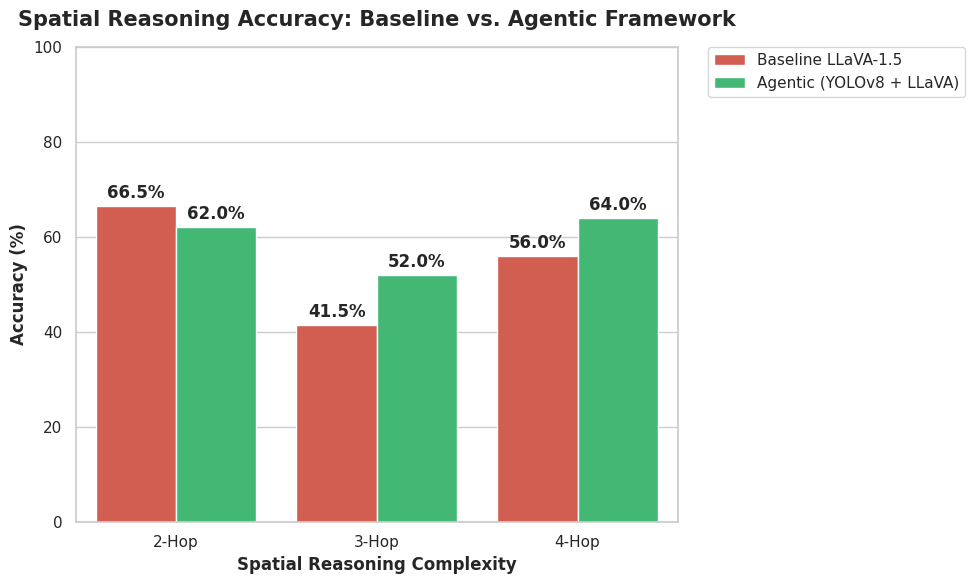

In [6]:
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. SET YOUR PATHS ---
# Make sure these point to your generated JSON files!
BASELINE_PATH = "/kaggle/input/notebooks/mohammadaliabdullah/deep-learning-project-baseline/unbiased_results.json" 
AGENTIC_PATH = "/kaggle/working/agentic_yolo_llava_results.json"

# --- 2. EVALUATION LOGIC ---
def calculate_accuracy(filepath):
    try:
        with open(filepath, "r") as f:
            results = json.load(f)
    except FileNotFoundError:
        print(f"⚠️ Could not find {filepath}. Is the path correct?")
        return None

    stats = {2: {"correct": 0, "total": 0}, 3: {"correct": 0, "total": 0}, 4: {"correct": 0, "total": 0}}
    
    for res in results:
        hop = res.get('hop_level')
        truth = str(res.get('ground_truth')).strip().lower()
        answer = str(res.get('model_answer', '')).strip().lower()
        
        if not answer: continue 
        
        if truth == "yes" and "yes" in answer:
            stats[hop]["correct"] += 1
        elif truth == "no" and ("no" in answer or "not" in answer or "none" in answer):
            stats[hop]["correct"] += 1
        elif truth in answer:
            stats[hop]["correct"] += 1
            
        stats[hop]["total"] += 1
        
    accuracies = {}
    for hop in [2, 3, 4]:
        if stats[hop]["total"] > 0:
            accuracies[f"{hop}-Hop"] = (stats[hop]["correct"] / stats[hop]["total"]) * 100
        else:
            accuracies[f"{hop}-Hop"] = 0.0
            
    return accuracies

# --- 3. CRUNCH THE DATA ---
print("Calculating accuracies...")
baseline_acc = calculate_accuracy(BASELINE_PATH)
agentic_acc = calculate_accuracy(AGENTIC_PATH)

if baseline_acc and agentic_acc:
    # Prepare data for Seaborn Pandas DataFrame
    data = []
    for hop in ["2-Hop", "3-Hop", "4-Hop"]:
        data.append({"Complexity": hop, "Accuracy": baseline_acc[hop], "Architecture": "Baseline LLaVA-1.5"})
        data.append({"Complexity": hop, "Accuracy": agentic_acc[hop], "Architecture": "Agentic (YOLOv8 + LLaVA)"})
        
    df = pd.DataFrame(data)

    # --- 4. GENERATE THE RESEARCH GRAPH ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # Create the grouped bar chart
    ax = sns.barplot(
        data=df, x="Complexity", y="Accuracy", hue="Architecture", 
        palette=["#e74c3c", "#2ecc71"] # Red for baseline, Green for Agentic
    )
    
    plt.title("Spatial Reasoning Accuracy: Baseline vs. Agentic Framework", fontsize=15, fontweight='bold', pad=15)
    plt.ylabel("Accuracy (%)", fontsize=12, fontweight='bold')
    plt.xlabel("Spatial Reasoning Complexity", fontsize=12, fontweight='bold')
    plt.ylim(0, 100)
    
    # Move the legend outside the chart so it doesn't block the bars
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    # Add exact percentage labels on top of every single bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', padding=3, fontweight='bold')
        
    plt.tight_layout()
    plt.show()
else:
    print("Waiting for both JSON files to be generated. Run this again later!")